# **Neural Network from Scratch**

In [10]:
import numpy as np
import matplotlib.pyplot as plt

**Define binary patterns for A, B, and C.**

In [11]:
A = np.array([
    [0,1,1,1,0],
    [1,0,0,0,1],
    [1,1,1,1,1],
    [1,0,0,0,1],
    [1,0,0,0,1],
    [0,0,0,0,0]
]).flatten()

B = np.array([
    [1,1,1,0,0],
    [1,0,0,1,0],
    [1,1,1,0,0],
    [1,0,0,1,0],
    [1,1,1,0,0],
    [0,0,0,0,0]
]).flatten()

C = np.array([
    [0,1,1,1,0],
    [1,0,0,0,1],
    [1,0,0,0,0],
    [1,0,0,0,1],
    [0,1,1,1,0],
    [0,0,0,0,0]
]).flatten()

# Dataset: each row is a letter
X = np.array([A, B, C])
y = np.array([[1,0,0], [0,1,0], [0,0,1]])  # One-hot encoded labels

**Define helper functions**

In [12]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)


**Initialize network parameters**

In [13]:
np.random.seed(42)
input_size = X.shape[1]   # 30 pixels
hidden_size = 10          # hidden neurons
output_size = 3           # A, B, C classes

W1 = np.random.randn(input_size, hidden_size)
b1 = np.zeros((1, hidden_size))
W2 = np.random.randn(hidden_size, output_size)
b2 = np.zeros((1, output_size))

**Training loop**

In [14]:
epochs = 10000
lr = 0.5
losses = []

for epoch in range(epochs):
    # Feedforward
    z1 = np.dot(X, W1) + b1
    a1 = sigmoid(z1)
    z2 = np.dot(a1, W2) + b2
    a2 = sigmoid(z2)

    # Compute loss
    loss = mse(y, a2)
    losses.append(loss)

    # Backpropagation
    error_output = y - a2
    d_output = error_output * sigmoid_derivative(a2)

    error_hidden = np.dot(d_output, W2.T)
    d_hidden = error_hidden * sigmoid_derivative(a1)

    # Update weights and biases
    W2 += np.dot(a1.T, d_output) * lr
    b2 += np.sum(d_output, axis=0, keepdims=True) * lr
    W1 += np.dot(X.T, d_hidden) * lr
    b1 += np.sum(d_hidden, axis=0, keepdims=True) * lr

    # Print progress
    if epoch % 1000 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.6f}")

Epoch 0, Loss: 0.455453
Epoch 1000, Loss: 0.000403
Epoch 2000, Loss: 0.000193
Epoch 3000, Loss: 0.000127
Epoch 4000, Loss: 0.000094
Epoch 5000, Loss: 0.000074
Epoch 6000, Loss: 0.000062
Epoch 7000, Loss: 0.000052
Epoch 8000, Loss: 0.000046
Epoch 9000, Loss: 0.000040


**Evaluate model**

In [15]:
z1 = np.dot(X, W1) + b1
a1 = sigmoid(z1)
z2 = np.dot(a1, W2) + b2
output = sigmoid(z2)

predictions = np.argmax(output, axis=1)
true_labels = np.argmax(y, axis=1)
accuracy = np.mean(predictions == true_labels)

print("\nFinal Training Accuracy:", accuracy)
print("Predictions:", predictions)
print("True Labels:", true_labels)


Final Training Accuracy: 1.0
Predictions: [0 1 2]
True Labels: [0 1 2]


**Plot loss curve**

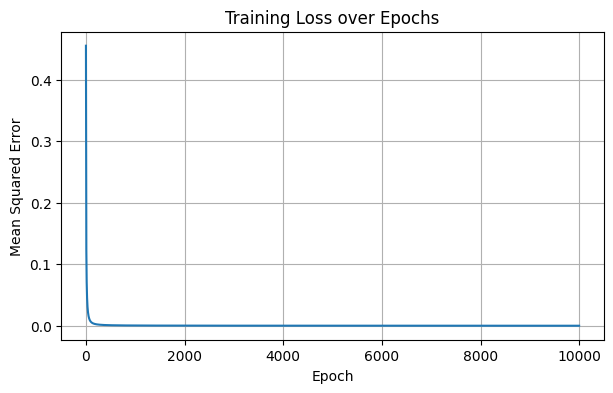

In [16]:
plt.figure(figsize=(7,4))
plt.plot(losses)
plt.title("Training Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.grid(True)
plt.show()

**Visualize predictions**

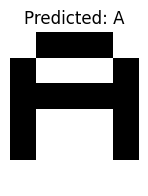

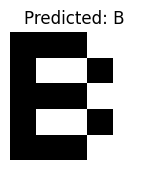

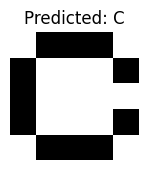

In [17]:
letters = ['A', 'B', 'C']

for i, letter in enumerate(X):
    plt.figure(figsize=(2,2))
    plt.imshow(letter.reshape(6,5), cmap='binary')
    plt.title(f"Predicted: {letters[predictions[i]]}")
    plt.axis('off')
    plt.show()

**Test on a noisy input**

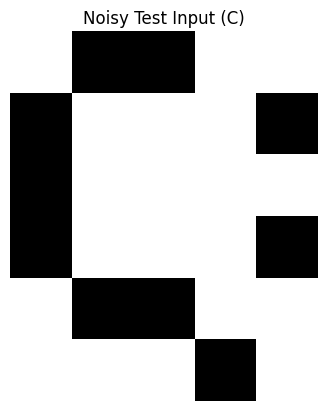


Prediction for noisy C: C


In [18]:
def add_noise(img, noise_level=0.2):
    noisy = img.copy()
    n = int(len(img) * noise_level)
    idx = np.random.choice(len(img), n, replace=False)
    noisy[idx] = 1 - noisy[idx]
    return noisy

test_img = add_noise(C, 0.1)
plt.imshow(test_img.reshape(6,5), cmap='binary')
plt.title("Noisy Test Input (C)")
plt.axis('off')
plt.show()

# Predict noisy input
z1 = np.dot(test_img.reshape(1, -1), W1) + b1
a1 = sigmoid(z1)
z2 = np.dot(a1, W2) + b2
pred = sigmoid(z2)

print("\nPrediction for noisy C:", letters[np.argmax(pred)])